# Pipeline predictivo del PIB per cápita estatal en México: integrando educación, inversión, remesas y violencia (2006-2023)

Importación de Librerias y Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("merged_data.csv")

# Analisis Exploratorio

Vista General

In [ ]:
print('   1. Información básica'   )
print(df.info())

print('   2. Estadísticas descriptivas'   )
print(df.describe())

print("   3. Valores nulos"   )
print(df.isnull().sum())

   1. Información básica
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   estado                576 non-null    object 
 1   año                   576 non-null    int64  
 2   pibe_millones         576 non-null    int64  
 3   poblacion             576 non-null    int64  
 4   pib_per_capita        576 non-null    int64  
 5   pct_secundario        576 non-null    float64
 6   pct_terciario         576 non-null    float64
 7   informalidad_pct      576 non-null    float64
 8   escolaridad_promedio  576 non-null    float64
 9   ied_mdd               576 non-null    float64
 10  remesas_mdd           576 non-null    float64
 11  homicidios_100k       576 non-null    float64
dtypes: float64(7), int64(4), object(1)
memory usage: 54.1+ KB
None
   2. Estadísticas descriptivas
               año  pibe_millones     poblacion  pib_per

Distribución Visual

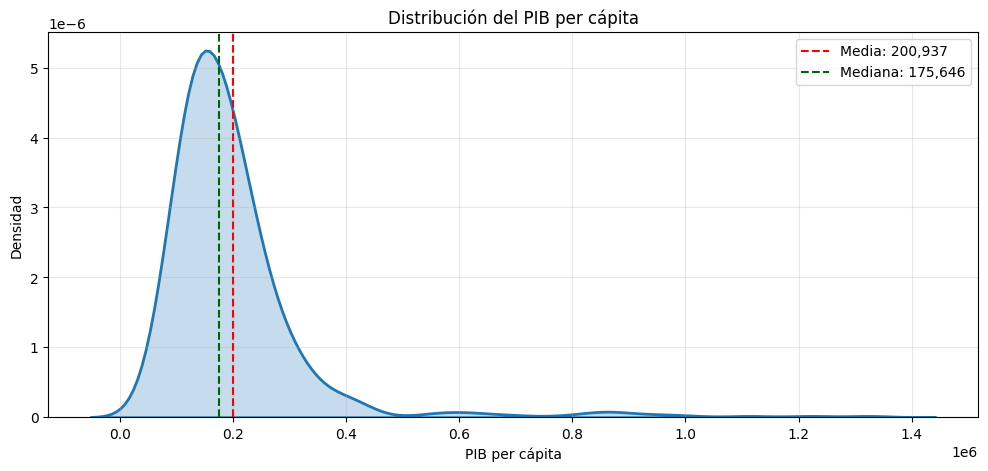

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.kdeplot(df['pib_per_capita'], fill=True, linewidth=2, ax=ax)
for val, color, label in [
    (df['pib_per_capita'].mean(), 'red', 'Media'),
    (df['pib_per_capita'].median(), 'darkgreen', 'Mediana'),
]:
    ax.axvline(val, color=color, linestyle='--', label=f'{label}: {val:,.0f}')
ax.set(title='Distribución del PIB per cápita', xlabel='PIB per cápita', ylabel='Densidad')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

Estádisticas de la Variable Objetivo

In [ ]:
print("Estadísticas de la variable objetivo")
print(f"Mínimo: {df["pib_per_capita"].min():,.0f}")
print(f"Máximo: {df['pib_per_capita'].max():,.0f}")
print(f"Media: {df["pib_per_capita"].mean():,.0f}")
print(f"Mediana: {df['pib_per_capita'].median():,.0f}")
print(f"Sesgo: {df['pib_per_capita'].skew():.2f}")

Estadísticas de la variable objetivo
Mínimo: 65,475
Máximo: 1,325,471
Media: 200,937
Mediana: 175,646
Sesgo: 4.15


Evolución Temporal de los Estados Más Altos y Más Bajos

In [ ]:
print("---Estados con PIBE per cápita (último año) más altos y bajos---")
ultimo_año = df['año'].max()
ultimo_df = df[df['año'] == ultimo_año].sort_values('pib_per_capita', ascending=False)
print(f"\nEstados con mayor PIB per cápita ({ultimo_año})")
print(ultimo_df[['estado', 'pib_per_capita']].head(5))
print(f"\nEstados con menor PIB per cápita ({ultimo_año})")
print(ultimo_df[['estado', 'pib_per_capita']].tail(5))

---Estados con PIBE per cápita (último año) más altos y bajos---

Estados con mayor PIB per cápita (2023)
                   estado  pib_per_capita
547              Campeche          570084
552      Ciudad de México          418245
562            Nuevo León          312739
548  Coahuila de Zaragoza          273173
569                Sonora          251951

Estados con menor PIB per cápita (2023)
       estado  pib_per_capita
564    Puebla          112659
563    Oaxaca          105716
572  Tlaxcala          105669
555  Guerrero           83442
550   Chiapas           68009


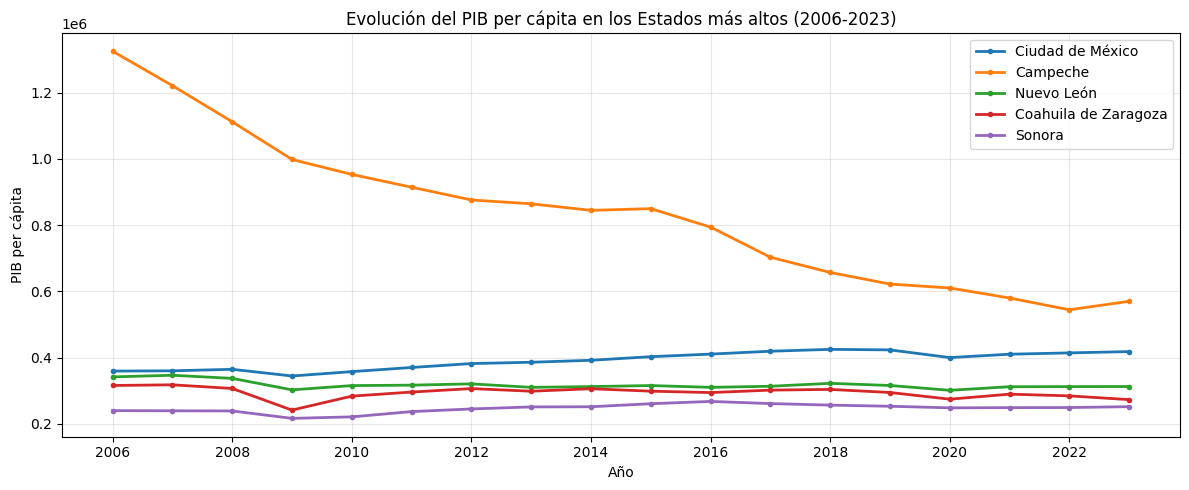

In [ ]:
estados_altos = ["Ciudad de México", 'Campeche', 'Nuevo León', "Coahuila de Zaragoza", 'Sonora']

fig, ax = plt.subplots(figsize=(12, 5))
for estado in estados_altos:
    subset = df[df["estado"] == estado]
    ax.plot(subset['año'], subset['pib_per_capita'], marker='.', label=estado, linewidth=2)

ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_title('Evolución del PIB per cápita en los Estados más altos (2006-2023)')
ax.set_xlabel('Año')
ax.set_ylabel('PIB per cápita')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

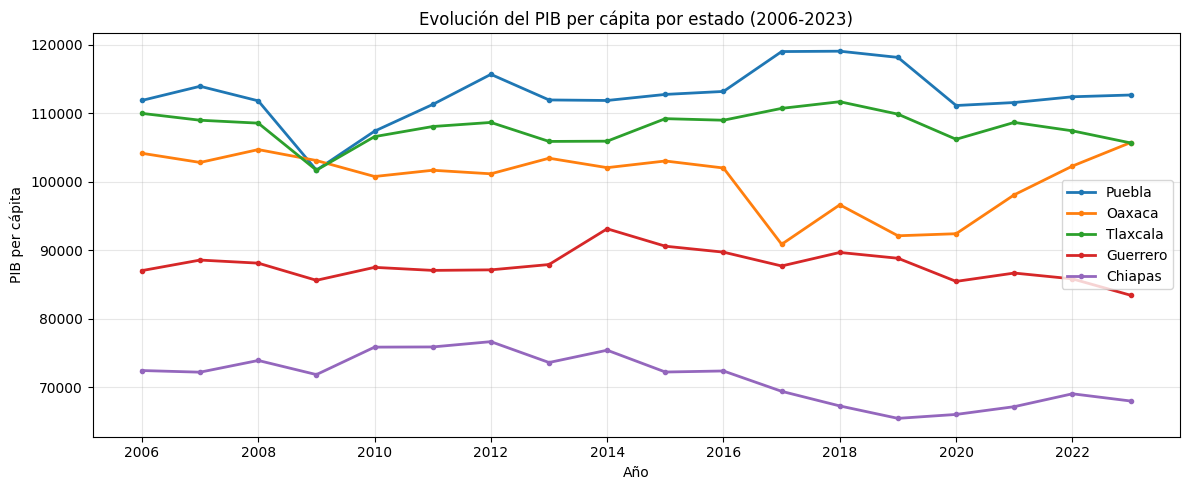

In [ ]:
estados_bajos = ['Puebla', 'Oaxaca', 'Tlaxcala', 'Guerrero', 'Chiapas']

fig, ax = plt.subplots(figsize=(12, 5))
for estado in estados_bajos:
    subset = df[df['estado'] == estado]
    ax.plot(subset['año'], subset['pib_per_capita'], marker='.', label=estado, linewidth=2)

ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_title('Evolución del PIB per cápita por estado (2006-2023)')
ax.set_xlabel('Año')
ax.set_ylabel('PIB per cápita')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Mátriz de Correlación

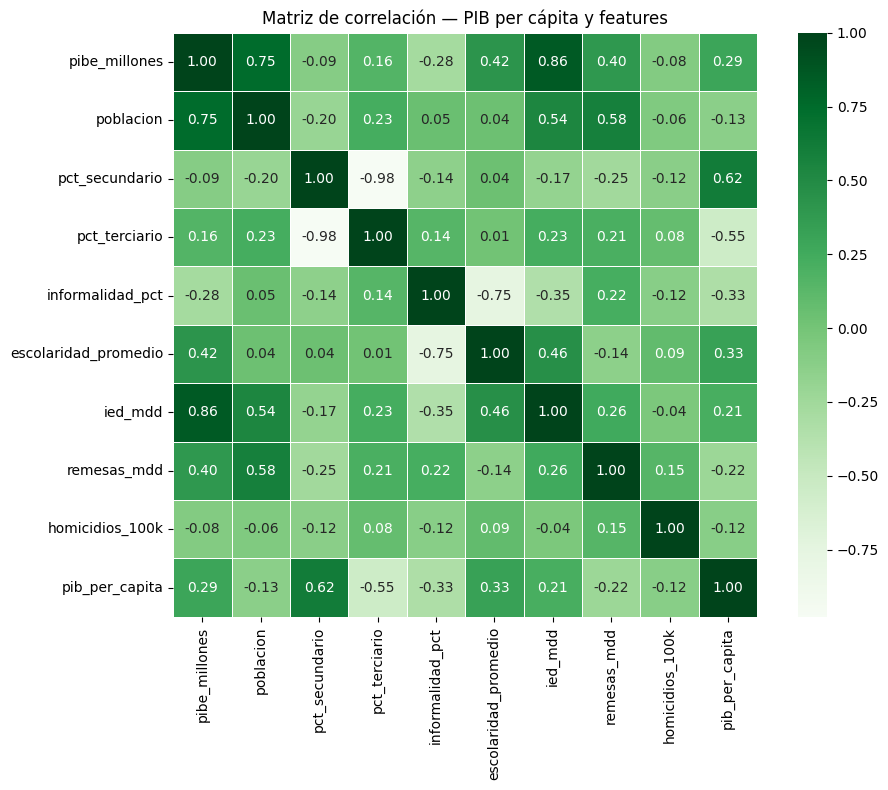


---Correlación con PIB per cápita---
pib_per_capita          1.000000
pct_secundario          0.619559
escolaridad_promedio    0.325101
pibe_millones           0.291840
ied_mdd                 0.213790
homicidios_100k        -0.116096
poblacion              -0.132902
remesas_mdd            -0.222584
informalidad_pct       -0.333610
pct_terciario          -0.548727
Name: pib_per_capita, dtype: float64


In [ ]:
features = ['pibe_millones', 'poblacion', 'pct_secundario', 'pct_terciario',
            'informalidad_pct', 'escolaridad_promedio', 'ied_mdd', 'remesas_mdd', 'homicidios_100k']

corr = df[features + ["pib_per_capita"]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Greens', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Matriz de correlación — PIB per cápita y features")
plt.tight_layout(); plt.show()

corr_target = corr['pib_per_capita'].sort_values(ascending=False)
print("\n---Correlación con PIB per cápita---")
print(corr_target)

Análisis de Outliers

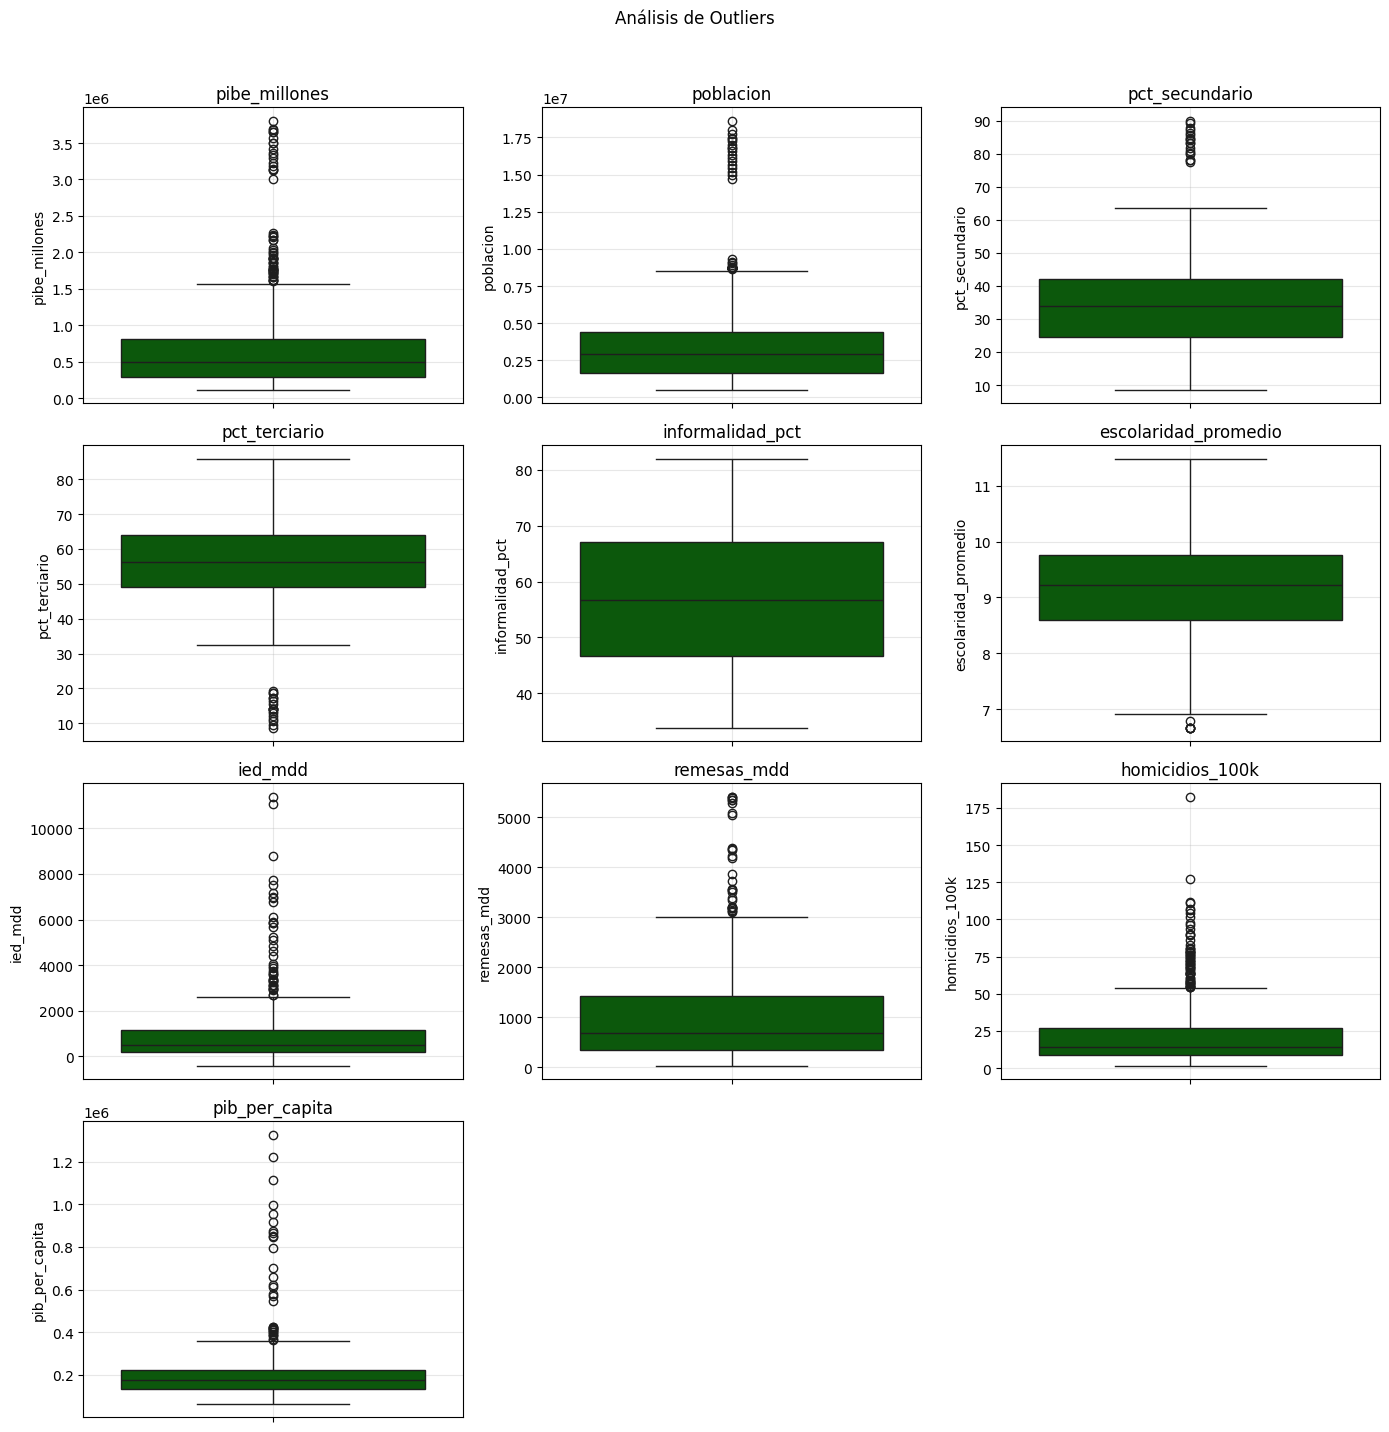

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(features + ['pib_per_capita']):
    sns.boxplot(y=df[col], ax=axes[i], color='darkgreen')
    axes[i].set_title(col)
    axes[i].grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Análisis de Outliers', y=1.02)
plt.tight_layout(); plt.show()

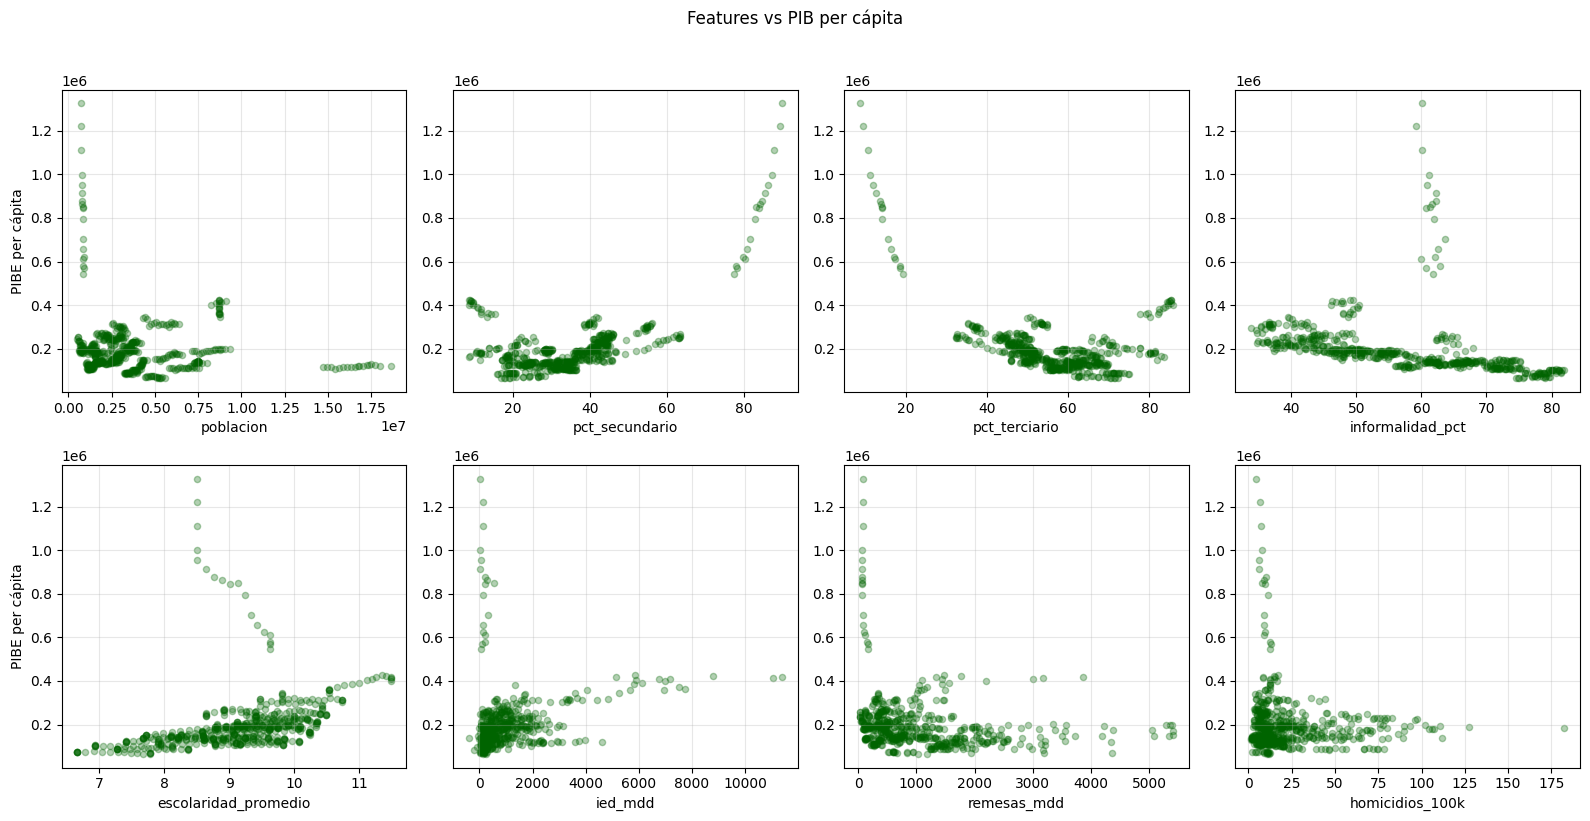

In [ ]:
features = ['poblacion', 'pct_secundario', 'pct_terciario', 'informalidad_pct',
            'escolaridad_promedio', 'ied_mdd', 'remesas_mdd', 'homicidios_100k']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].scatter(df[col], df['pib_per_capita'], alpha=0.3, s=20, color='darkgreen')
    axes[i].set(xlabel=col, ylabel='PIBE per cápita' if i % 4 == 0 else '')
    axes[i].grid(alpha=0.3)

plt.suptitle("Features vs PIB per cápita", y=1.02)
plt.tight_layout()
plt.show()

Conclusiones

- El PIB per cápita tiene distribución asimétrica con outliers persistentes
  cómo Campeche. Se aplicará transformación logarítmica en preprocesamiento para que el modelo no se enfoque de más con esté estado.

- `ied_mdd` y `remesas_mdd` mostraron una estructura similar en sus scatter plots entonces puede que también se aplique la transformación logarítmica.

- `pct_terciario` (-0.98) se descartan una de las dos por multicolinealidad severa con `pct_secundario`. Se conserva `pct_secundario` (correlación 0.62).

- `escolaridad_promedio` muestra la relación más limpia y consistente con el target.

- `ied_mdd`, `remesas_mdd` y `homicidios_100k` tienen distribuciones con cola
  larga y poca estructura lineal — se evaluará su utilidad en el modelado.

- Las relaciones no lineales observadas justifican el uso de modelos como
  XGBoost o Random Forest sobre regresión lineal.

# Preprocesamiento

Elección de Features Finales y Transformación Logartimica

In [ ]:
features = ['poblacion', 'pct_secundario', 'informalidad_pct',
            'escolaridad_promedio', 'ied_mdd', 'remesas_mdd', 'homicidios_100k']

df['log_pib_per_capita'] = np.log(df['pib_per_capita'])

X = df[features]
y = df['log_pib_per_capita']

Train, Test, Split

In [ ]:
train = df[df['año'] < 2020]
test  = df[df['año'] >= 2020]

X_train = train[features]
X_test  = test[features]
y_train = train['log_pib_per_capita']
y_test  = test['log_pib_per_capita']

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (448, 7) | Test: (128, 7)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Modelo Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2   = r2_score(y_test, y_pred_ridge)

print(f"Ridge — RMSE: {rmse:.4f} | R²: {r2:.4f}")

Ridge — RMSE: 0.2437 | R²: 0.6839


/tmp/ipykernel_5764/2033697926.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  ax.plot([y_test.min(), y_test.max()],


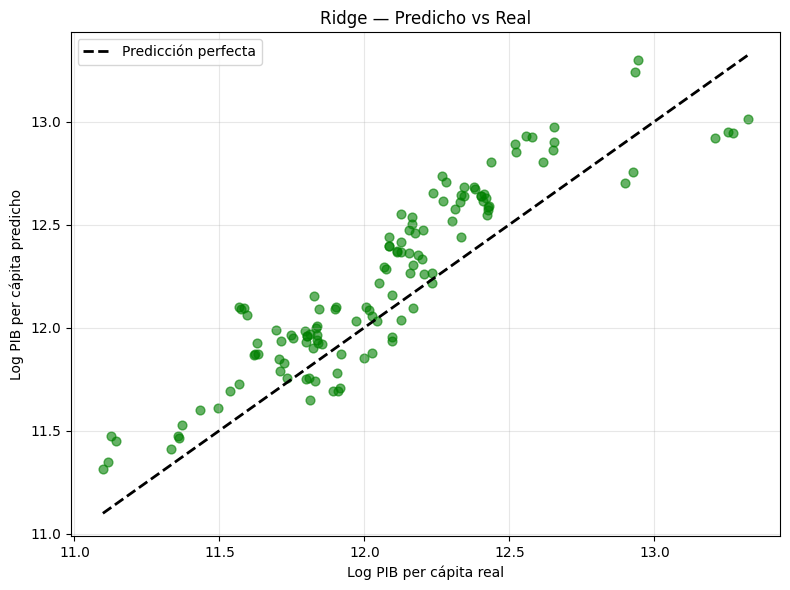

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred_ridge, alpha=0.6, s=40, color='green')
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', linewidth=2, label='Predicción perfecta', color='black')
ax.set(title='Ridge — Predicho vs Real',
       xlabel='Log PIB per cápita real',
       ylabel='Log PIB per cápita predicho')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

El valor de R2 alcanzó a 0.68 y y el RMSE a 0.24 (escala log). El modelo captura tendencias generales pero limitado por que el dataset tiene relaciones no lineales.

Se espera que con Random Forest el R2 alcance 0.80 y el RMSE baje.

# Modelo Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"Random Forest — RMSE: {rmse_rf:.4f} | R²: {r2_rf:.4f}")

Random Forest — RMSE: 0.1336 | R²: 0.9050


/tmp/ipykernel_5764/3858970528.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  ax.plot([y_test.min(), y_test.max()],


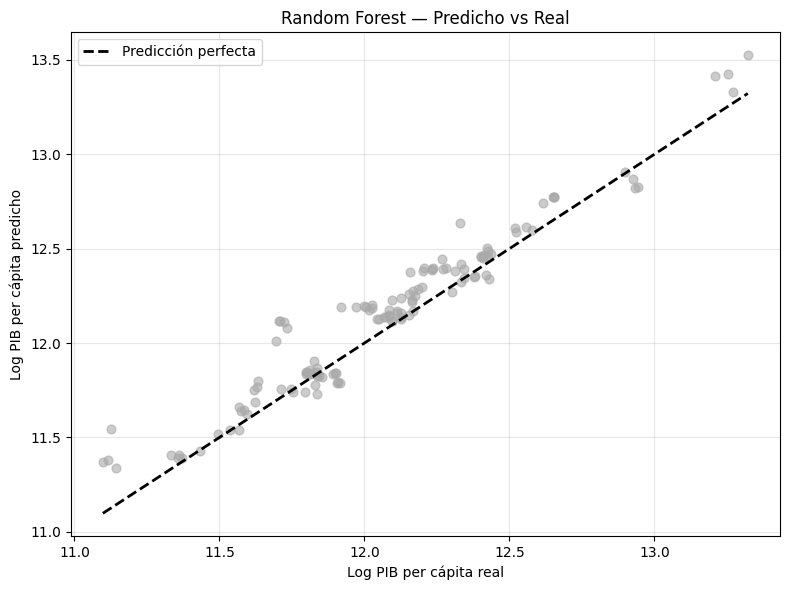

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred_rf, alpha=0.6, s=40, color='darkgrey')
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', linewidth=2, label='Predicción perfecta', color='black')
ax.set(title='Random Forest — Predicho vs Real',
       xlabel='Log PIB per cápita real',
       ylabel='Log PIB per cápita predicho')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Random Forest logró R2=0.90 y RMSE=0.13, una mejora significativa sobre Ridge. Confirma que las relaciones entre las variables socioeconómicas y el PIB per cápita son no lineales.

# Modelo XG Boost

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb.fit(X_train_scaled, y_train)

y_pred_xgb = xgb.predict(X_test_scaled)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb   = r2_score(y_test, y_pred_xgb)

print(f"XGBoost — RMSE: {rmse_xgb:.4f} | R²: {r2_xgb:.4f}")

XGBoost — RMSE: 0.1881 | R²: 0.8117


/tmp/ipykernel_5764/965332559.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  ax.plot([y_test.min(), y_test.max()],


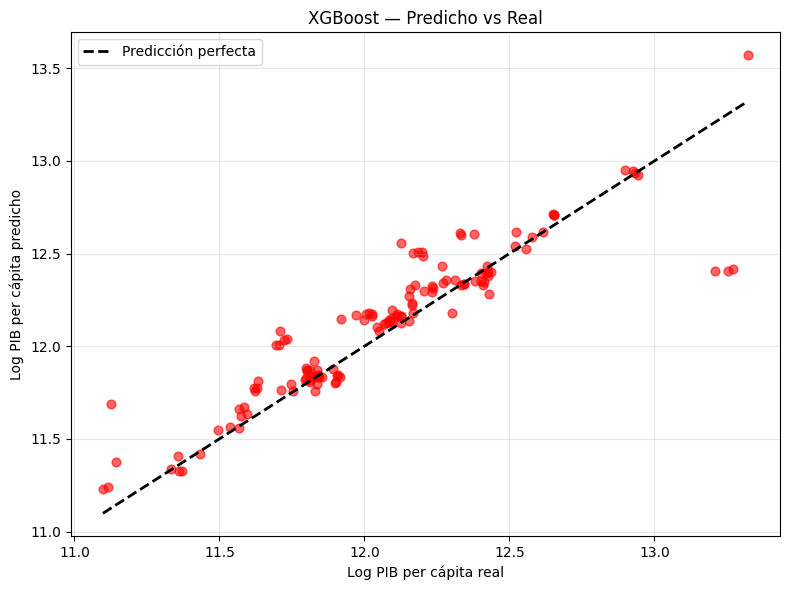

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred_xgb, alpha=0.6, s=40, color="red")
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        "r--", linewidth=2, label="Predicción perfecta", color="black")
ax.set(title="XGBoost — Predicho vs Real",
       xlabel="Log PIB per cápita real",
       ylabel="Log PIB per cápita predicho")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

XGBoost con parámetros anteriores obtuvo R2=0.81 y RMSE=0.19,
por debajo de Random Forest. Con un ajuste de hiperparámetros
podría mejorar.

## Evaluación

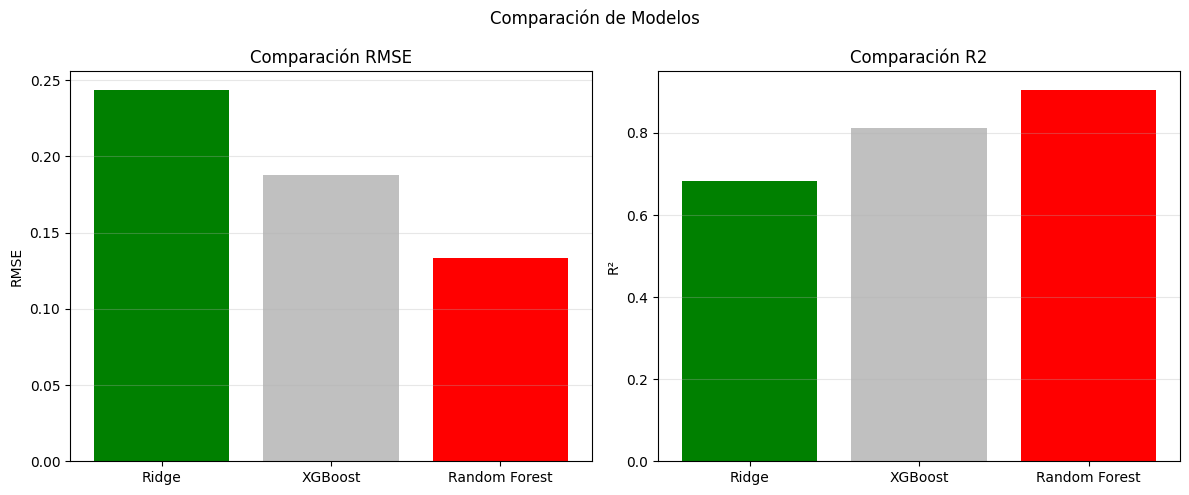

In [ ]:
modelos = ['Ridge', 'XGBoost', 'Random Forest']
rmse_vals = [0.2437, 0.1881, 0.1336]
r2_vals   = [0.6839, 0.8117, 0.9050]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(modelos, rmse_vals, color=['green', 'silver', 'red'])
axes[0].set(title='Comparación RMSE', ylabel='RMSE')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(modelos, r2_vals, color=['green', 'silver', 'red'])
axes[1].set(title='Comparación R2', ylabel='R²')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("Comparación de Modelos")
plt.tight_layout()
plt.show()

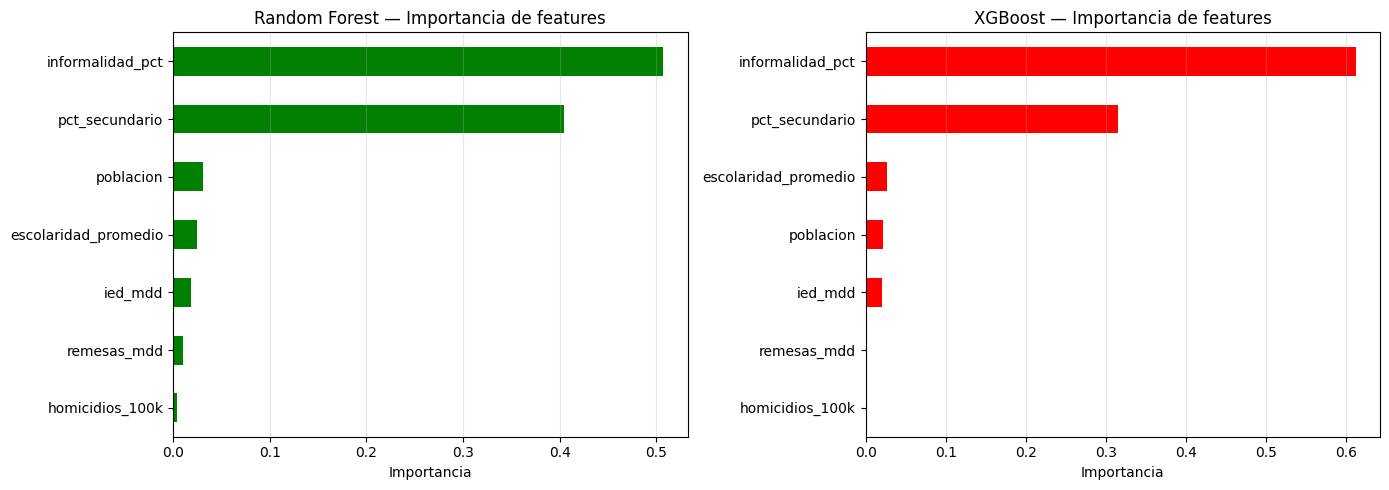

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
pd.Series(rf.feature_importances_, index=features).sort_values().plot(
    kind='barh', ax=axes[0], color='green')
axes[0].set(title='Random Forest — Importancia de features', xlabel='Importancia')
axes[0].grid(axis='x', alpha=0.3)

# XGBoost
pd.Series(xgb.feature_importances_, index=features).sort_values().plot(
    kind='barh', ax=axes[1], color='red')
axes[1].set(title='XGBoost — Importancia de features', xlabel='Importancia')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

- Ambos modelos coinciden en que `escolaridad_promedio` y
  `pct_secundario` son las variables más determinantes del
  PIB per cápita estatal. Resultó consistente con el EDA.
- `homicidios_100k`, `ied_mdd` y `remesas_mdd` resultaron
  poco relevantes para el modelo.

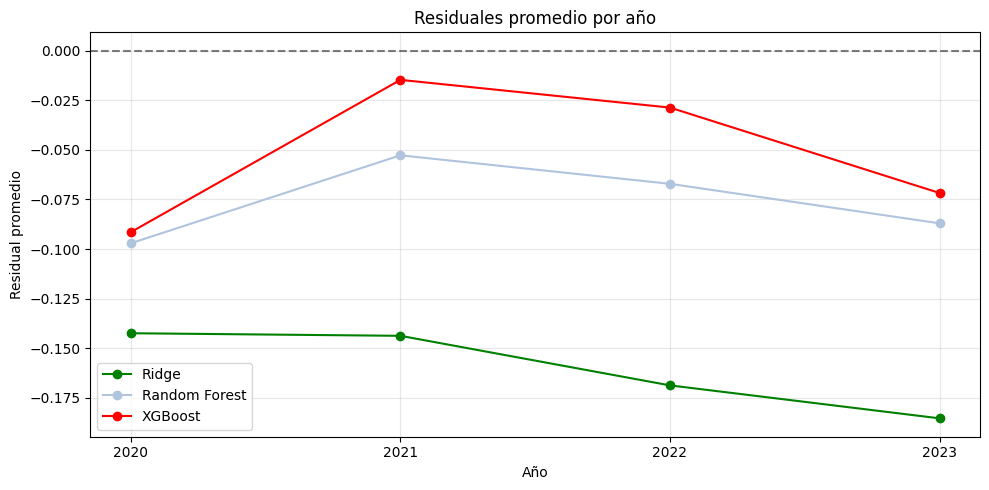

In [ ]:
test_copy = test.copy()
test_copy['residual_ridge'] = y_test - y_pred_ridge
test_copy['residual_rf']    = y_test - y_pred_rf
test_copy['residual_xgb']   = y_test - y_pred_xgb

residuales_año = test_copy.groupby('año')[['residual_ridge', 'residual_rf', 'residual_xgb']].mean()

fig, ax = plt.subplots(figsize=(10, 5))
for col, label, color in zip(
    ['residual_ridge', 'residual_rf', 'residual_xgb'],
    ['Ridge', 'Random Forest', 'XGBoost'],
    ['green', 'lightsteelblue', 'red']
):
    ax.plot(residuales_año.index, residuales_año[col], marker='o', label=label, color=color)

ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.set(title='Residuales promedio por año', xlabel='Año', ylabel='Residual promedio')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- Los tres modelos sobreestiman en 2020 por el shock del COVID,
  evento no visto durante el entrenamiento.
- Random Forest y XGBoost se recuperan en 2021, Ridge no.
- La tendencia negativa 2022-2023 sugiere que la economía
  post-COVID tiene patrones distintos al período de entrenamiento.

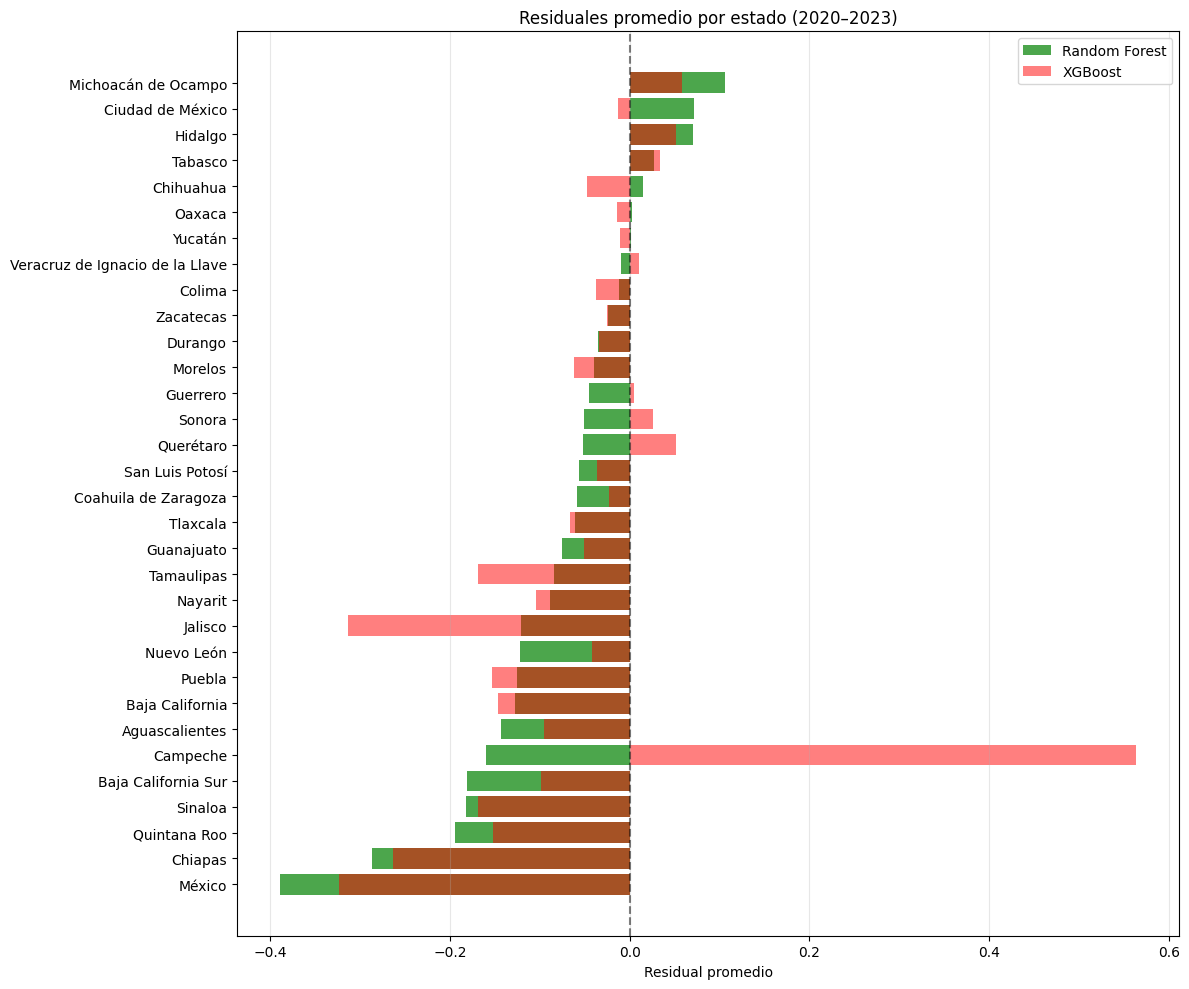

In [ ]:
residuales_estado = test_copy.groupby("estado")[['residual_ridge', 'residual_rf', 'residual_xgb']].mean().sort_values('residual_rf')

fig, ax = plt.subplots(figsize=(12, 10))
x = range(len(residuales_estado))
ax.barh(residuales_estado.index, residuales_estado['residual_rf'],
        color='green', alpha=0.7, label='Random Forest')
ax.barh(residuales_estado.index, residuales_estado['residual_xgb'],
        color='red', alpha=0.5, label='XGBoost')
ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.set(title="Residuales promedio por estado (2020–2023)",
       xlabel='Residual promedio', ylabel='')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

- Campeche y Estado de México son los estados más difíciles
  de predecir por razones opuestas: uno por riqueza atípica
  (petróleo), el otro por población masiva con bajo PIB per cápita.
- Los modelos coinciden en sus errores para la mayoría de estados,
  sugiriendo que las limitaciones vienen del dataset, no del algoritmo.
- Estados del centro y sur con economías más "típicas" son los
  mejor predichos por ambos modelos.


In [ ]:
from sklearn.metrics import mean_absolute_error

resultados = pd.DataFrame({
    'Modelo': ['Ridge', 'Random Forest', 'XGBoost'],
    'RMSE':   [np.sqrt(mean_squared_error(y_test, pred)) for pred in [y_pred_ridge, y_pred_rf, y_pred_xgb]],
    'MAE':    [mean_absolute_error(y_test, pred) for pred in [y_pred_ridge, y_pred_rf, y_pred_xgb]],
    'R²':     [r2_score(y_test, pred) for pred in [y_pred_ridge, y_pred_rf, y_pred_xgb]]
})

print(resultados.to_string(index=False))

       Modelo     RMSE      MAE       R²
        Ridge 0.243741 0.215424 0.683907
Random Forest 0.133602 0.098085 0.905030
      XGBoost 0.188130 0.112798 0.811689


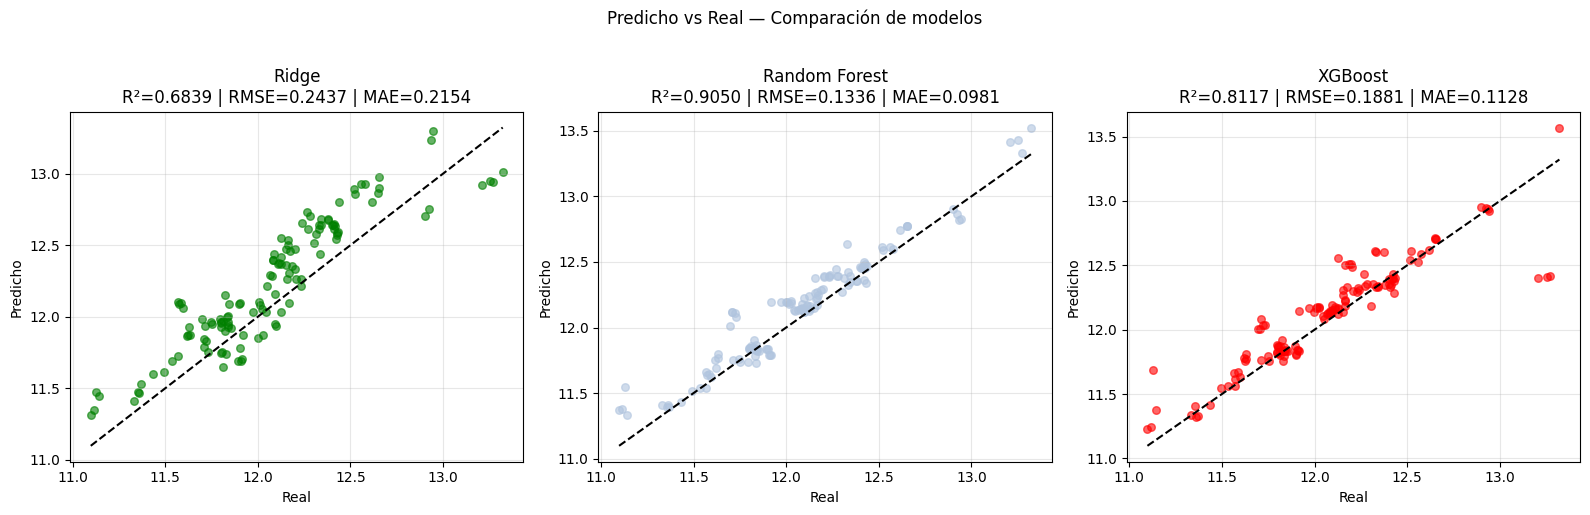

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

modelos_info = [
    ('Ridge', y_pred_ridge, 'green'),
    ('Random Forest', y_pred_rf, 'lightsteelblue'),
    ('XGBoost', y_pred_xgb, 'red')
]

for ax, (nombre, y_pred, color) in zip(axes, modelos_info):
    ax.scatter(y_test, y_pred, alpha=0.6, s=30, color=color)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'k--', linewidth=1.5)
    ax.set(title=f'{nombre}\nR²={r2_score(y_test, y_pred):.4f} | RMSE={np.sqrt(mean_squared_error(y_test, y_pred)):.4f} | MAE={mean_absolute_error(y_test, y_pred):.4f}',
           xlabel='Real', ylabel='Predicho')
    ax.grid(alpha=0.3)

plt.suptitle('Predicho vs Real — Comparación de modelos', y=1.02)
plt.tight_layout()
plt.show()

- Los tres modelos capturan la tendencia general del PIB per cápita,
  pero Random Forest mantiene menor dispersión en todo el rango de valores.
- Ridge falla principalmente en el rango medio (estados típicos).
- XGBoost tiene más errores en estados con PIB per cápita bajo.

## Ajustes

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3]
}

xgb_tuned = GridSearchCV(XGBRegressor(random_state=42, verbosity=0),
                          params, cv=5, scoring='r2', n_jobs=-1)
xgb_tuned.fit(X_train_scaled, y_train)

y_pred_xgb_tuned = xgb_tuned.predict(X_test_scaled)

print("Mejores parámetros:", xgb_tuned.best_params_)
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned)):.4f} | MAE: {mean_absolute_error(y_test, y_pred_xgb_tuned):.4f} | R2: {r2_score(y_test, y_pred_xgb_tuned):.4f}")

Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
RMSE: 0.1844 | MAE: 0.1154 | R2: 0.8190


XGBoost con tuning mejoró muy poco (R2=0.82 vs 0.81 original).
La mejora no es significativa, confirmando que el problema no es
de hiperparámetros sino que Random Forest se adapta mejor a la
estructura de este dataset.

In [ ]:
params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_leaf': [1, 2]
}

rf_tuned = GridSearchCV(RandomForestRegressor(random_state=42),
                         params, cv=3, scoring='r2', n_jobs=-1)
rf_tuned.fit(X_train_scaled, y_train)

y_pred_rf_tuned = rf_tuned.predict(X_test_scaled)

print("Mejores parámetros:", rf_tuned.best_params_)
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned)):.4f} | MAE: {mean_absolute_error(y_test, y_pred_rf_tuned):.4f} | R2: {r2_score(y_test, y_pred_rf_tuned):.4f}")

Mejores parámetros: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
RMSE: 0.1310 | MAE: 0.0971 | R2: 0.9088


Random Forest tuneado mejoró ligeramente (R2=0.9088 vs 0.9050 original).
  Los parámetros óptimos coinciden casi con los originales, confirmando
  que el modelo estaba bien configurado desde el inicio.
  Sigue siendo el mejor modelo del proyecto.

In [ ]:
# Validación cruzada

from sklearn.model_selection import TimeSeriesSplit, cross_val_score

df_sorted = df.sort_values(['año', 'estado'])

X_cv = df_sorted[features]
y_cv = df_sorted['log_pib_per_capita']

tscv = TimeSeriesSplit(n_splits=5)

scores = cross_val_score(
    RandomForestRegressor(n_estimators=200, random_state=42),
    X_cv, y_cv, cv=tscv, scoring='r2', n_jobs=-1
)

print(f"R2 por fold: {scores.round(4)}")
print(f"R2 promedio: {scores.mean():.4f} (+/- {scores.std():.4f})")

R2 por fold: [0.9576 0.926  0.9449 0.8775 0.9602]
R2 promedio: 0.9332 (+/- 0.0304)


- Cross-validation temporal confirmó la estructura del modelo:
  R2 promedio de 0.933 con desviación estándar de 0.030.
- El modelo generaliza bien a través de diferentes períodos,
  no depende de un rango de años específico para funcionar.
- El fold más bajo (0.877) coincide con períodos de mayor
  volatilidad económica.

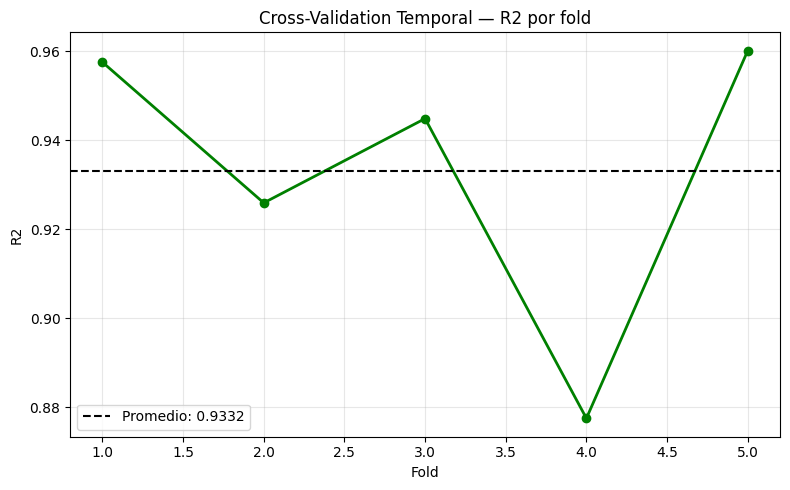

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, 6), scores, marker='o', linewidth=2, color='green')
ax.axhline(scores.mean(), color='black', linestyle='--',
           label=f'Promedio: {scores.mean():.4f}')
ax.set(title='Cross-Validation Temporal — R2 por fold',
       xlabel='Fold', ylabel='R2')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#Stacking

from sklearn.ensemble import StackingRegressor

estimadores = [
    ('ridge', Ridge(alpha=1.0)),
    ('rf', RandomForestRegressor(n_estimators=200, random_state=42)),
    ('xgb', XGBRegressor(learning_rate=0.1, max_depth=7,
                          n_estimators=200, random_state=42, verbosity=0))
]

stacking = StackingRegressor(estimators=estimadores,
                              final_estimator=Ridge(), cv=5)
stacking.fit(X_train_scaled, y_train)

y_pred_stack = stacking.predict(X_test_scaled)

print(f"Stacking — RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_stack)):.4f} | MAE: {mean_absolute_error(y_test, y_pred_stack):.4f} | R2: {r2_score(y_test, y_pred_stack):.4f}")

Stacking — RMSE: 0.1324 | MAE: 0.0999 | R2: 0.9067


- Stacking (Ridge + RF + XGBoost) obtuvo R2=0.906, sin superar
  a Random Forest tuned (R2=0.908). El stacking no aporta mejora significativa.
- Random Forest tuned es el modelo final del proyecto.

In [ ]:
resultados_finales = pd.DataFrame({
    'Modelo': ['RF Tuned', 'Stacking', 'RF Dummy Campeche', 'RF sin Campeche',
               'XGBoost Tuned', 'XGBoost Default', 'RF Default', 'Ridge'],
    'RMSE':   [0.1310, 0.1324, 0.1328, 0.1411, 0.1844, 0.1881, 0.1336, 0.2437],
    'MAE':    [0.0971, 0.0999, 0.0987, 0.0971, 0.1154, 0.1128, 0.0981, 0.2154],
    'R2':     [0.9088, 0.9067, 0.9062, 0.8638, 0.8190, 0.8117, 0.9050, 0.6839]
}).sort_values('R2', ascending=False).reset_index(drop=True)

print(resultados_finales.to_string(index=False))

           Modelo   RMSE    MAE     R2
         RF Tuned 0.1310 0.0971 0.9088
         Stacking 0.1324 0.0999 0.9067
RF Dummy Campeche 0.1328 0.0987 0.9062
       RF Default 0.1336 0.0981 0.9050
  RF sin Campeche 0.1411 0.0971 0.8638
    XGBoost Tuned 0.1844 0.1154 0.8190
  XGBoost Default 0.1881 0.1128 0.8117
            Ridge 0.2437 0.2154 0.6839


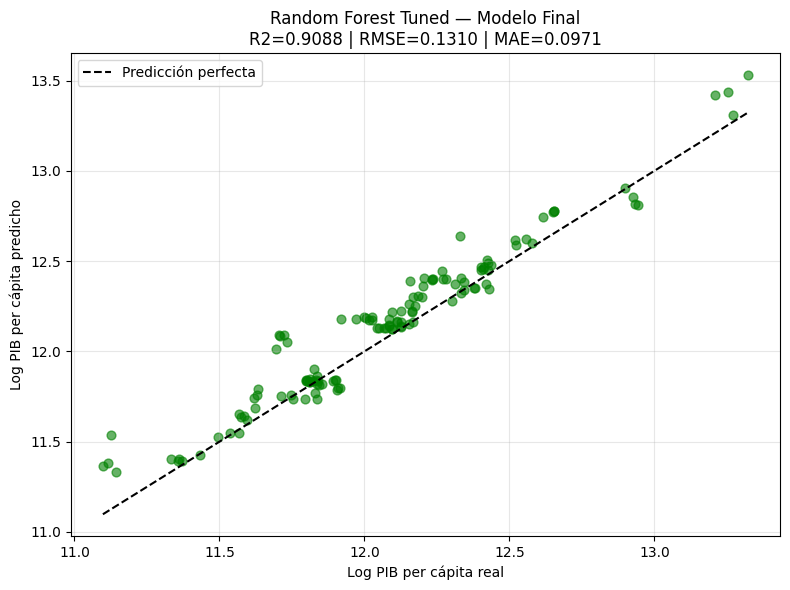

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred_rf_tuned, alpha=0.6, s=40, color='green')
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'k--', linewidth=1.5, label='Predicción perfecta')
ax.set(title=f'Random Forest Tuned — Modelo Final\nR2=0.9088 | RMSE=0.1310 | MAE=0.0971',
       xlabel='Log PIB per cápita real',
       ylabel='Log PIB per cápita predicho')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()